In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from tslearn.clustering import TimeSeriesKMeans
from tslearn.metrics import cdist_dtw
from sklearn.metrics import silhouette_score
import os
import math

In [3]:
files = [
    "aisdk-2025-09-21.csv",
    "aisdk-2025-09-22.csv",
    "aisdk-2025-09-23.csv",
]

file_list = ", ".join([f"'{f}'" for f in files])

tmpdir = os.path.expanduser("~/duckdb_tmp")
os.makedirs(tmpdir, exist_ok=True)

con = duckdb.connect("ais_work.duckdb")
con.execute(f"SET temp_directory='{tmpdir}';")
con.execute("SET max_temp_directory_size='100GiB';")
con.execute("SET memory_limit='4GiB';")
con.execute("SET threads=1;")
con.execute("SET preserve_insertion_order=false;")

source_sql = f"""
SELECT *
FROM read_csv(
    [{file_list}],
    header = true,
    union_by_name = true,
    delim = ',',
    quote = '"',
    escape = '"',
    null_padding = true,
    strict_mode = false
)
"""

cols_df = con.execute(f"DESCRIBE {source_sql}").fetchdf()
all_cols = cols_df["column_name"].tolist()

group_cols = ['# Timestamp', 'MMSI']
other_cols = [c for c in all_cols if c not in group_cols]

select_parts = ['"# Timestamp"', '"MMSI"']
select_parts += [f'ANY_VALUE("{c}") AS "{c}"' for c in other_cols]

select_sql = ",\n        ".join(select_parts)

query = f"""
COPY (
    SELECT
        {select_sql}
    FROM ({source_sql}) t
    GROUP BY "# Timestamp", MMSI
) TO 'ais_2ivykis.csv' (HEADER, DELIMITER ',');
"""

con.execute(query)

print("Baigta: sukurtas failas ais_2ivykis.csv")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Baigta: sukurtas failas ais_4days_dedup.csv


In [2]:

df = pd.read_csv("ais_2ivykis.csv")
print(df.shape)
print(df.info())

(31648324, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31648324 entries, 0 to 31648323
Data columns (total 26 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   # Timestamp                     object 
 1   MMSI                            int64  
 2   Type of mobile                  object 
 3   Latitude                        float64
 4   Longitude                       float64
 5   Navigational status             object 
 6   ROT                             float64
 7   SOG                             float64
 8   COG                             float64
 9   Heading                         float64
 10  IMO                             object 
 11  Callsign                        object 
 12  Name                            object 
 13  Ship type                       object 
 14  Cargo type                      object 
 15  Width                           float64
 16  Length                          float64
 17  Type of po

In [3]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('#', '', regex=False)
)
df = df.rename(columns={'_timestamp': 'timestamp'})

df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True, errors='coerce')


df = df.drop(columns=['cargo_type'], errors='ignore')
df['ship_type'] = df['ship_type'].str.strip().str.lower()
df = df[df['ship_type'].isin(['cargo', 'tanker'])].copy()

print(df.columns.tolist())

/var/folders/l7/zz2kjwks3lgfb825_3dd3ghc0000gn/T/ipykernel_51559/3025262795.py:10: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True, errors='coerce')


['timestamp', 'mmsi', 'type_of_mobile', 'latitude', 'longitude', 'navigational_status', 'rot', 'sog', 'cog', 'heading', 'imo', 'callsign', 'name', 'ship_type', 'width', 'length', 'type_of_position_fixing_device', 'draught', 'destination', 'eta', 'data_source_type', 'a', 'b', 'c', 'd']


In [4]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': df.isna().mean() * 100
}).sort_values('missing_pct', ascending=False)

In [5]:
# garbage values
for col in ['type_of_mobile', 'ship_type', 'navigational_status',
            'type_of_position_fixing_device', 'destination']:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False).head(20))


--- type_of_mobile ---
type_of_mobile
Class A    7988377
Class B      26431
Name: count, dtype: int64

--- ship_type ---
ship_type
cargo     5665185
tanker    2349623
Name: count, dtype: int64

--- navigational_status ---
navigational_status
Under way using engine                 7229463
Constrained by her draught              290411
Moored                                  270092
At anchor                                79628
Under way sailing                        60986
Unknown value                            56424
Power-driven vessel towing astern        18825
Restricted maneuverability                5446
Not under command                         1833
Reserved for future amendment [HSC]       1700
Name: count, dtype: int64

--- type_of_position_fixing_device ---
type_of_position_fixing_device
GPS                             7303535
Combined GPS/GLONASS             322796
Internal                         206745
Undefined                        145724
Galileo                       

In [6]:
df_ship = df[df['type_of_mobile'].isin(['Class A', 'Class B'])].copy()
df_ship.head()

,timestamp,mmsi,type_of_mobile,latitude,longitude,navigational_status,rot,sog,cog,heading,...,length,type_of_position_fixing_device,draught,destination,eta,data_source_type,a,b,c,d
32,2025-09-21 00:00:56,538008283,Class A,56.631525,11.812967,Under way using engine,0.0,13.3,37.0,34.0,...,186.0,GPS,10.1,SKAGEN,2025-09-21 07:00:00,AIS,154.0,32.0,6.0,22.0
49,2025-09-21 00:01:24,246541000,Class A,55.787492,10.760435,At anchor,0.0,0.0,145.1,210.0,...,116.0,GPS,5.1,DKKAL,2025-09-19 17:00:00,AIS,105.0,11.0,14.0,1.0
51,2025-09-21 00:01:27,246507000,Class A,55.584668,12.700485,Under way using engine,0.0,7.9,175.9,175.0,...,111.0,GPS,6.8,MUUGA,2025-09-23 10:00:00,AIS,97.0,14.0,3.0,11.0
62,2025-09-21 00:01:54,374220000,Class A,56.906637,7.749470,Under way using engine,2.2,11.5,200.0,201.0,...,183.0,Undefined,7.3,FOR ORDER,2025-09-22 01:00:00,AIS,147.0,36.0,7.0,25.0
66,2025-09-21 00:02:01,305703000,Class A,54.654138,10.982118,Under way using engine,0.0,10.0,122.1,124.0,...,132.0,Combined GPS/GLONASS,7.8,LT KLJ,2025-09-22 16:00:00,AIS,120.0,12.0,11.0,5.0


In [7]:
print("Eilučių:", len(df_ship))
print("Unikalių laivų:", df_ship['mmsi'].nunique())

print("\nType of mobile:")
print(df_ship['type_of_mobile'].value_counts())

print("\nShip type:")
print(df_ship['ship_type'].value_counts(dropna=False).head(20))

Eilučių: 8014808
Unikalių laivų: 1064

Type of mobile:
type_of_mobile
Class A    7988377
Class B      26431
Name: count, dtype: int64

Ship type:
ship_type
cargo     5665185
tanker    2349623
Name: count, dtype: int64


In [8]:
name_counts = (
    df_ship.groupby('mmsi')['name']
    .nunique(dropna=True)
    .sort_values(ascending=False)
)

In [9]:
name_map = (
    df_ship.dropna(subset=['name'])
    .groupby('mmsi')['name']
    .agg(lambda s: s.value_counts().index[0])
)

missing_before = df_ship['name'].isna().sum()

df_ship['name_filled'] = df_ship['name'].fillna(
    df_ship['mmsi'].map(name_map)
)

missing_after = df_ship['name_filled'].isna().sum()

print("Trūko prieš:", missing_before)
print("Trūko po:", missing_after)

Trūko prieš: 3400
Trūko po: 3


In [10]:
invalid_cog = df_ship['cog'].notna() & ~df_ship['cog'].between(0, 360, inclusive='both')
invalid_heading = df_ship['heading'].notna() & ~df_ship['heading'].between(0, 360, inclusive='both')

print("Neteisingų COG:", invalid_cog.sum())
print("Neteisingų heading:", invalid_heading.sum())

Neteisingų COG: 0
Neteisingų heading: 1


In [11]:
df_ship.loc[invalid_cog, 'cog'] = np.nan
df_ship.loc[invalid_heading, 'heading'] = np.nan

In [12]:
df_ship['time_diff_sec'] = (
    df_ship.groupby('mmsi')['timestamp']
    .diff()
    .dt.total_seconds()
)

print(df_ship['time_diff_sec'].describe())
print("time_diff <= 0:", (df_ship['time_diff_sec'] <= 0).sum())
print("time_diff < 10 sec:", (df_ship['time_diff_sec'] < 10).sum())
print("time_diff < 1h:", (df_ship['time_diff_sec'] < 3600).sum())
print("time_diff > 1h:", (df_ship['time_diff_sec'] > 3600).sum())

count    8.013744e+06
mean     1.365108e+01
std      2.647812e+04
min     -2.591400e+05
25%      5.390000e+02
50%      1.512000e+03
75%      3.339000e+03
max      2.579330e+05
Name: time_diff_sec, dtype: float64
time_diff <= 0: 428091
time_diff < 10 sec: 447416
time_diff < 1h: 6182921
time_diff > 1h: 1828298


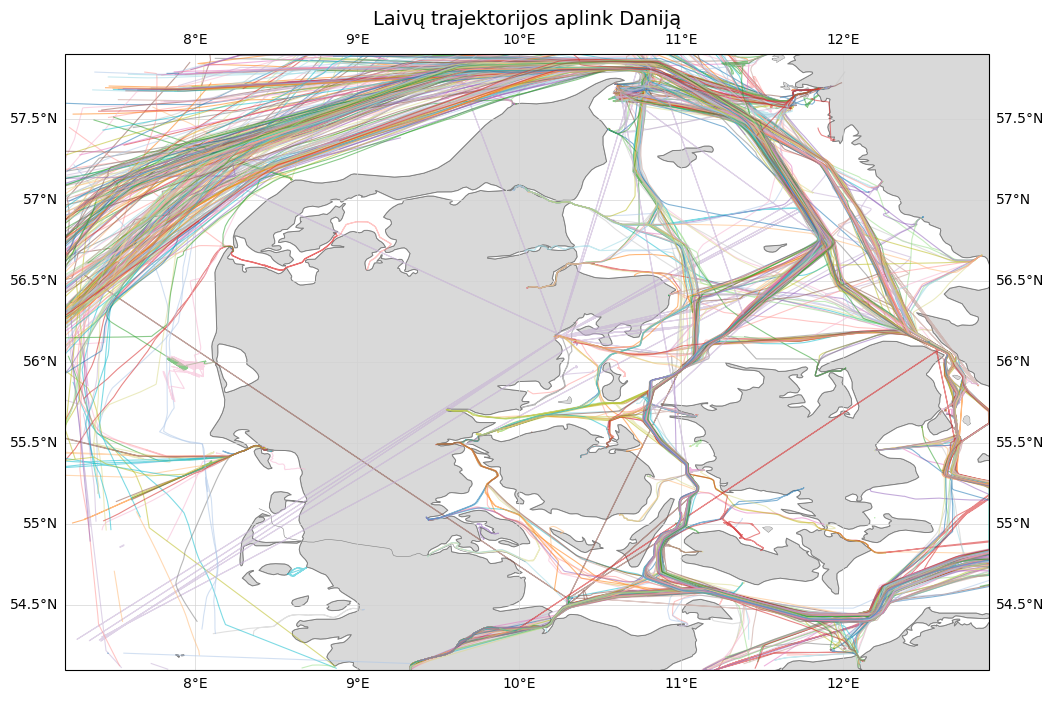

In [13]:
lon_min, lon_max = 7.2, 12.9
lat_min, lat_max = 54.1, 57.9
df_ship.sort_values(['mmsi', 'timestamp'], inplace=True)
# 2. Pasiliekam tik taškus tame regione
df_plot = df_ship[
    df_ship['longitude'].between(lon_min, lon_max) &
    df_ship['latitude'].between(lat_min, lat_max)
].copy()

# 4. Braižymas
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Fonas
ax.set_facecolor('#f2f2f2')
ax.add_feature(cfeature.LAND, facecolor='#d9d9d9', edgecolor='gray', linewidth=0.6, zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7, edgecolor='gray')
ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor='gray')

# Tinklelis ir geografinės etiketės
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.6,
    color='lightgray',
    alpha=0.8,
    linestyle='-'
)
gl.top_labels = True
gl.right_labels = True
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Spalvos trajektorijoms
cmap = plt.cm.tab20
mmsi_list = df_plot['mmsi'].drop_duplicates().tolist()

for i, mmsi in enumerate(mmsi_list):
    g = df_plot[df_plot['mmsi'] == mmsi]
    ax.plot(
        g['longitude'].values,
        g['latitude'].values,
        transform=ccrs.PlateCarree(),
        linewidth=0.8,
        alpha=0.55,
        color=cmap(i % 20)
    )

plt.title('Laivų trajektorijos aplink Daniją', fontsize=14)
plt.show()

In [14]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def clean_ship_jumps_iterative_drop_bad(df_ship, maxspeedknots=30, max_iter=20):
    df = df_ship.sort_values(['mmsi', 'timestamp']).copy()

    # 1. Blogos koordinatės -> išmetam tik eilutes
    invalid_coord = (
        (df['latitude'] >= 90) |
        (df['latitude'] <= -90) |
        (df['longitude'] > 180) |
        (df['longitude'] < -180)
    )

    bad_coord_rows = int(invalid_coord.sum())
    bad_coord_vessels = df.loc[invalid_coord, 'mmsi'].nunique()

    print("Blogų koordinačių eilučių:", bad_coord_rows)
    print("Laivų su blogom koordinatėm:", bad_coord_vessels)

    df = df[~invalid_coord].copy()

    history = []

    # 2. Iteracinis jump valymas
    for it in range(1, max_iter + 1):
        n_before = len(df)

        df = df.sort_values(['mmsi', 'timestamp']).copy()

        df['prevlat'] = df.groupby('mmsi')['latitude'].shift(1)
        df['prevlon'] = df.groupby('mmsi')['longitude'].shift(1)
        df['prevtime'] = df.groupby('mmsi')['timestamp'].shift(1)

        df['dthours'] = (
            (df['timestamp'] - df['prevtime']).dt.total_seconds() / 3600
        )

        df['distkm'] = haversine_km(
            df['prevlat'],
            df['prevlon'],
            df['latitude'],
            df['longitude']
        )

        df['speedkmh_implied'] = df['distkm'] / df['dthours']
        df['speedknotsimplied'] = df['speedkmh_implied'] / 1.852

        jump_mask = (
            (df['dthours'] > 0) &
            (df['speedknotsimplied'] > maxspeedknots)
        )

        n_jumps = int(jump_mask.sum())

        history.append({
            'iteration': it,
            'rows_before': n_before,
            'jump_rows_removed': n_jumps
        })

        print(f"Iteracija {it}: jump eilučių = {n_jumps}")

        if n_jumps == 0:
            print("Daugiau šuolių nebeliko.")
            break

        df = df[~jump_mask].copy()

    if n_jumps > 0:
        print(f"Pasiektas max_iter={max_iter}, dar yra likusių šuolių.")

    # 3. Galutinis likusių jump'ų tikrinimas
    df = df.sort_values(['mmsi', 'timestamp']).copy()

    df['prevlat'] = df.groupby('mmsi')['latitude'].shift(1)
    df['prevlon'] = df.groupby('mmsi')['longitude'].shift(1)
    df['prevtime'] = df.groupby('mmsi')['timestamp'].shift(1)

    df['dthours'] = (
        (df['timestamp'] - df['prevtime']).dt.total_seconds() / 3600
    )

    df['distkm'] = haversine_km(
        df['prevlat'],
        df['prevlon'],
        df['latitude'],
        df['longitude']
    )

    df['speedkmh_implied'] = df['distkm'] / df['dthours']
    df['speedknotsimplied'] = df['speedkmh_implied'] / 1.852

    final_jump_mask = (
        (df['dthours'] > 0) &
        (df['speedknotsimplied'] > maxspeedknots)
    )

    remaining_jump_rows = int(final_jump_mask.sum())
    print("Likusių jump eilučių po iteracinio valymo:", remaining_jump_rows)

    bad_jump_vessels = df.loc[final_jump_mask, 'mmsi'].unique()
    print("Probleminių MMSI po iteracinio valymo:", len(bad_jump_vessels))
    print("Pirmi keli probleminiai MMSI:", bad_jump_vessels[:20])

    # 4. Išmetam visus dar probleminius laivus
    df = df[~df['mmsi'].isin(bad_jump_vessels)].copy()

    print("Shape po probleminių MMSI išmetimo:", df.shape)

    # 5. Final sanity check
    df = df.sort_values(['mmsi', 'timestamp']).copy()

    df['prevlat'] = df.groupby('mmsi')['latitude'].shift(1)
    df['prevlon'] = df.groupby('mmsi')['longitude'].shift(1)
    df['prevtime'] = df.groupby('mmsi')['timestamp'].shift(1)

    df['dthours'] = (
        (df['timestamp'] - df['prevtime']).dt.total_seconds() / 3600
    )

    df['distkm'] = haversine_km(
        df['prevlat'],
        df['prevlon'],
        df['latitude'],
        df['longitude']
    )

    df['speedkmh_implied'] = df['distkm'] / df['dthours']
    df['speedknotsimplied'] = df['speedkmh_implied'] / 1.852

    final_check_mask = (
        (df['dthours'] > 0) &
        (df['speedknotsimplied'] > maxspeedknots)
    )

    print("Likusių jump eilučių po probleminių MMSI išmetimo:", int(final_check_mask.sum()))

    history_df = pd.DataFrame(history)

    df_clean = df.drop(columns=[
        'prevlat', 'prevlon', 'prevtime',
        'dthours', 'distkm', 'speedkmh_implied', 'speedknotsimplied'
    ], errors='ignore').reset_index(drop=True)

    return df_clean, history_df, bad_jump_vessels


# PALEIDIMAS
df_ship_clean, jump_cleaning_history, bad_jump_vessels = clean_ship_jumps_iterative_drop_bad(
    df_ship,
    maxspeedknots=30,
    max_iter=10
)

display(jump_cleaning_history)
print("Probleminių MMSI skaičius:", len(bad_jump_vessels))
print("Probleminių MMSI:", bad_jump_vessels)
print(df_ship_clean.shape)

Blogų koordinačių eilučių: 951
Laivų su blogom koordinatėm: 134
Iteracija 1: jump eilučių = 67239
Iteracija 2: jump eilučių = 6860
Iteracija 3: jump eilučių = 1102
Iteracija 4: jump eilučių = 350
Iteracija 5: jump eilučių = 154
Iteracija 6: jump eilučių = 86
Iteracija 7: jump eilučių = 67
Iteracija 8: jump eilučių = 46
Iteracija 9: jump eilučių = 38
Iteracija 10: jump eilučių = 32
Pasiektas max_iter=10, dar yra likusių šuolių.
Likusių jump eilučių po iteracinio valymo: 27
Probleminių MMSI po iteracinio valymo: 18
Pirmi keli probleminiai MMSI: [211833390 218055710 219281000 219629000 230642000 257550000 266247000
 311000973 311046100 477293800 477895400 538010533 572561220 636017059
 636018554 636019884 636025205 636091130]
Shape po probleminių MMSI išmetimo: (7717834, 34)
Likusių jump eilučių po probleminių MMSI išmetimo: 0


,iteration,rows_before,jump_rows_removed
0,1,8013857,67239
1,2,7946618,6860
2,3,7939758,1102
3,4,7938656,350
4,5,7938306,154
5,6,7938152,86
6,7,7938066,67
7,8,7937999,46
8,9,7937953,38
9,10,7937915,32


Probleminių MMSI skaičius: 18
Probleminių MMSI: [211833390 218055710 219281000 219629000 230642000 257550000 266247000
 311000973 311046100 477293800 477895400 538010533 572561220 636017059
 636018554 636019884 636025205 636091130]
(7717834, 27)


In [15]:
df_ship = df_ship_clean.copy()

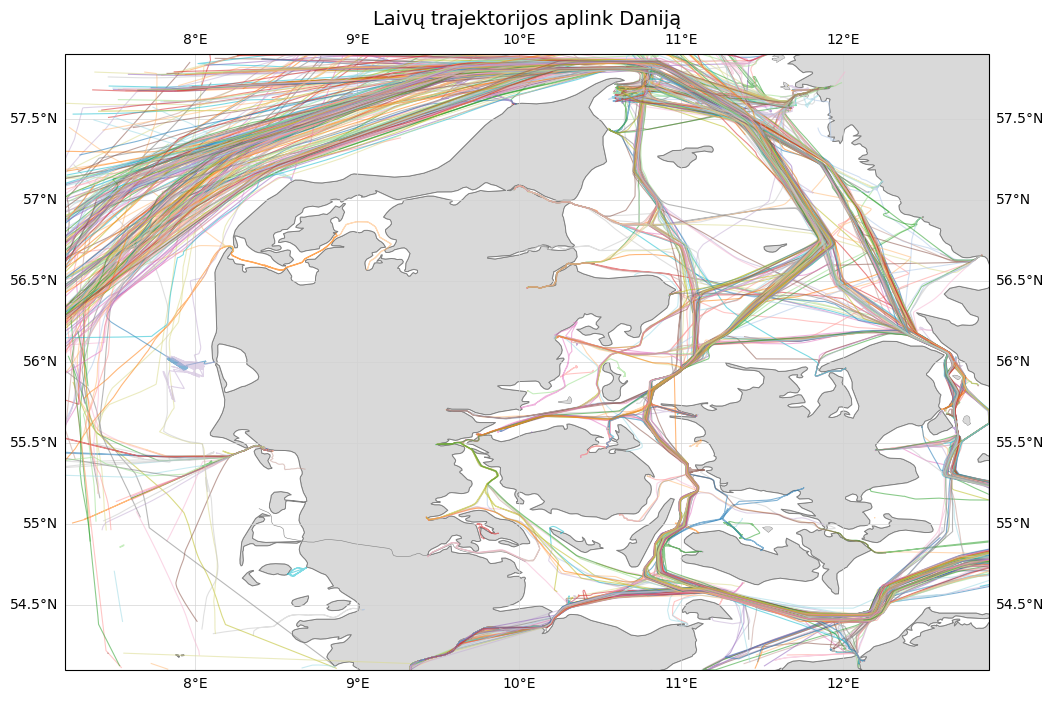

In [16]:
# 1. Pasirenkam regioną aplink Daniją
lon_min, lon_max = 7.2, 12.9
lat_min, lat_max = 54.1, 57.9

# 2. Pasiliekam tik taškus tame regione
df_plot = df_ship[
    df_ship['longitude'].between(lon_min, lon_max) &
    df_ship['latitude'].between(lat_min, lat_max)
].copy()

# 4. Braižymas
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Fonas
ax.set_facecolor('#f2f2f2')
ax.add_feature(cfeature.LAND, facecolor='#d9d9d9', edgecolor='gray', linewidth=0.6, zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7, edgecolor='gray')
ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor='gray')

# Tinklelis ir geografinės etiketės
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.6,
    color='lightgray',
    alpha=0.8,
    linestyle='-'
)
gl.top_labels = True
gl.right_labels = True
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Spalvos trajektorijoms
cmap = plt.cm.tab20
mmsi_list = df_plot['mmsi'].drop_duplicates().tolist()

for i, mmsi in enumerate(mmsi_list):
    g = df_plot[df_plot['mmsi'] == mmsi]
    ax.plot(
        g['longitude'].values,
        g['latitude'].values,
        transform=ccrs.PlateCarree(),
        linewidth=0.8,
        alpha=0.55,
        color=cmap(i % 20)
    )

plt.title('Laivų trajektorijos aplink Daniją', fontsize=14)
plt.show()

In [17]:
df_ship_1 = df_ship[['timestamp', 'mmsi', 'latitude', 'longitude']].copy()


In [18]:
# -----------------------------
# PARAMETERS
# -----------------------------
RESAMPLE_FREQ = '2min'
MAX_GAP = 3600  # 1 hour


# -----------------------------
# 1. SORT DATA
# -----------------------------
df_1 = df_ship_1.sort_values(['mmsi', 'timestamp']).copy()


# -----------------------------
# 2. COMPUTE TIME GAPS
# -----------------------------
df_1['time_gap_sec'] = (
    df_1.groupby('mmsi')['timestamp']
    .diff()
    .dt.total_seconds()
)

# naujas blokas prasideda kai tarpas > MAX_GAP
df_1['new_block'] = (
    df_1['time_gap_sec'].isna() |
    (df_1['time_gap_sec'] > MAX_GAP)
)

# kiekvienam laivui sunumeruojam blokus
df_1['block_id'] = (
    df_1.groupby('mmsi')['new_block']
    .cumsum()
)


# -----------------------------
# 3. RESAMPLING FUNCTION
# -----------------------------
def resample_ship_block(group, mmsi, block_id):
    if len(group) < 2:
        return None

    group = (
        group.sort_values('timestamp')
        .drop_duplicates('timestamp')
        .set_index('timestamp')
    )

    if group.index.min() == group.index.max():
        return None

    grid = pd.date_range(
        start=group.index.min().ceil(RESAMPLE_FREQ),
        end=group.index.max().floor(RESAMPLE_FREQ),
        freq=RESAMPLE_FREQ
    )

    if len(grid) == 0:
        return None

    tmp = group.reindex(group.index.union(grid)).sort_index()

    tmp[['latitude', 'longitude']] = (
        tmp[['latitude', 'longitude']]
        .interpolate(method='time', limit_area='inside')
    )

    tmp = tmp.loc[grid, ['latitude', 'longitude']].reset_index()
    tmp = tmp.rename(columns={'index': 'timestamp'})
    tmp['mmsi'] = mmsi
    tmp['block_id'] = block_id

    return tmp[['timestamp', 'mmsi', 'block_id', 'latitude', 'longitude']]


# -----------------------------
# 4. APPLY
# -----------------------------
parts_1 = []

for (mmsi, block_id), group in df_1.groupby(['mmsi', 'block_id']):
    res = resample_ship_block(group, mmsi, block_id)
    if res is not None and not res.empty:
        parts_1.append(res)

df_resampled_1 = pd.concat(parts_1, ignore_index=True)


# -----------------------------
# RESULT
# -----------------------------
df_resampled_1.head()

,timestamp,mmsi,block_id,latitude,longitude
0,2025-09-21 09:22:00,205011000,2,54.153490,9.374533
1,2025-09-21 09:24:00,205011000,2,54.155364,9.380608
2,2025-09-21 09:26:00,205011000,2,54.157238,9.386684
3,2025-09-21 09:28:00,205011000,2,54.158768,9.393032
4,2025-09-21 09:30:00,205011000,2,54.160280,9.399391


In [19]:
df_resampled_1['mmsi'].nunique()

1037

In [20]:
# TRAJECTORY WINDOWS / SEQUENCES

WINDOW_SIZE = 20
STEP_SIZE = 10   # 50% overlap


# tik dėl saugumo
df_seq_src_1 = (
    df_resampled_1[['timestamp', 'mmsi', 'block_id', 'latitude', 'longitude']]
    .sort_values(['mmsi', 'block_id', 'timestamp'])
    .reset_index(drop=True)
    .copy()
)


sequence_metadata_1 = []
sequence_arrays_1 = []
original_sequences_1 = []


sequence_id = 0


for (mmsi, block_id), group in df_seq_src_1.groupby(['mmsi', 'block_id']):
    group = group.sort_values('timestamp').reset_index(drop=True)

    n = len(group)
    if n < WINDOW_SIZE:
        continue

    for start_idx in range(0, n - WINDOW_SIZE + 1, STEP_SIZE):
        end_idx = start_idx + WINDOW_SIZE

        window = group.iloc[start_idx:end_idx].copy()

        # 20x2 masyvas DTW etapui
        coords = window[['latitude', 'longitude']].to_numpy()

        start = coords[0]
        coords_relative = coords - start

        sequence_arrays_1.append(coords_relative)
        original_sequences_1.append(coords)

        sequence_metadata_1.append({
            'sequence_id': sequence_id,
            'mmsi': mmsi,
            'block_id': block_id,
            'start_time': window['timestamp'].iloc[0],
            'end_time': window['timestamp'].iloc[-1],
            'window_start_idx': start_idx,
            'window_end_idx': end_idx - 1
        })

        sequence_id += 1


# metadata lentelė
sequence_metadata_df_1 = pd.DataFrame(sequence_metadata_1)


print("Sekų skaičius:", len(sequence_arrays_1))
print("Metadata shape:", sequence_metadata_df_1.shape)
sequence_metadata_df_1.head()

Sekų skaičius: 91784
Metadata shape: (91784, 7)


,sequence_id,mmsi,block_id,start_time,end_time,window_start_idx,window_end_idx
0,0,205011000,2,2025-09-21 09:22:00,2025-09-21 10:00:00,0,19
1,1,205011000,2,2025-09-21 09:42:00,2025-09-21 10:20:00,10,29
2,2,205011000,2,2025-09-21 10:02:00,2025-09-21 10:40:00,20,39
3,3,205011000,2,2025-09-21 10:22:00,2025-09-21 11:00:00,30,49
4,4,205011000,2,2025-09-21 10:42:00,2025-09-21 11:20:00,40,59


In [21]:
# pirma seka
print(sequence_metadata_df_1.iloc[0])
print(sequence_arrays_1[0].shape)   # turėtų būti (20, 2)
print(sequence_arrays_1[0])

sequence_id                           0
mmsi                          205011000
block_id                              2
start_time          2025-09-21 09:22:00
end_time            2025-09-21 10:00:00
window_start_idx                      0
window_end_idx                       19
Name: 0, dtype: object
(20, 2)
[[0.         0.        ]
 [0.00187398 0.00607527]
 [0.00374796 0.01215054]
 [0.00527869 0.01849928]
 [0.00679036 0.02485777]
 [0.00829858 0.03122414]
 [0.00989837 0.03753993]
 [0.01152452 0.04378065]
 [0.01328273 0.05002884]
 [0.01516527 0.05618253]
 [0.01703688 0.06238743]
 [0.01897451 0.06857789]
 [0.0209709  0.07460395]
 [0.02263937 0.08086203]
 [0.02402999 0.08734521]
 [0.02542729 0.09375997]
 [0.02684333 0.10021758]
 [0.02819927 0.10662169]
 [0.02951927 0.11305531]
 [0.03084773 0.11947377]]


In [22]:
sequence_metadata_df_1.groupby('mmsi').size().sort_values(ascending=False).head(10)

mmsi
677064088    214
218058660    214
219007671    214
219007462    214
219004907    214
219003966    214
219003452    214
219003383    214
219003113    214
257872000    214
dtype: int64

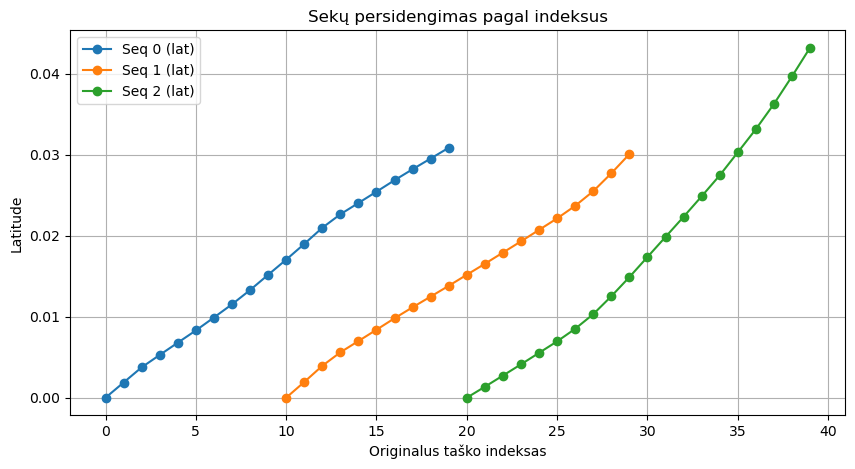

In [23]:
seq_ids = [0, 1, 2]

plt.figure(figsize=(10, 5))

for seq_id in seq_ids:
    coords = sequence_arrays_1[seq_id]
    start = sequence_metadata_df_1.iloc[seq_id]["window_start_idx"]
    x = np.arange(start, start + len(coords))

    plt.plot(x, coords[:, 0], marker='o', label=f'Seq {seq_id} (lat)')
    
plt.xlabel("Originalus taško indeksas")
plt.ylabel("Latitude")
plt.title("Sekų persidengimas pagal indeksus")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# kiek sekų turi kiekvienas laivas visame rinkinyje
all_vessel_seq_counts_1 = sequence_metadata_df_1.groupby('mmsi').size()

# dažnių lentelė visam rinkiniui
all_freq_table_1 = (
    all_vessel_seq_counts_1
    .value_counts()
    .sort_index(ascending=False)
    .reset_index()
)

all_freq_table_1.columns_1 = ['n_sequences', 'n_vessels']
all_freq_table_1

/var/folders/l7/zz2kjwks3lgfb825_3dd3ghc0000gn/T/ipykernel_51559/2081002903.py:12: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  all_freq_table_1.columns_1 = ['n_sequences', 'n_vessels']


,index,count
0,214,108
1,213,5
2,210,3
3,209,4
4,208,3
...,...,...
194,5,10
195,4,10
196,3,12
197,2,10


In [25]:
all_vessel_seq_counts_1.describe()

count    1016.000000
mean       90.338583
std        68.948282
min         1.000000
25%        31.000000
50%        74.000000
75%       142.000000
max       214.000000
dtype: float64

In [26]:
# Paliekame visus laivus, nes ir tie, kurie turi mažai sekų,
# gali būti potencialios anomalijos.

vessel_seq_counts_all_1 = sequence_metadata_df_1.groupby('mmsi').size()

filtered_metadata_df_1 = (
    sequence_metadata_df_1
    .sort_values(['mmsi', 'block_id', 'sequence_id'])
    .reset_index(drop=True)
    .copy()
)

filtered_sequence_ids_1 = filtered_metadata_df_1['sequence_id'].tolist()
filtered_sequence_arrays_1 = [sequence_arrays_1[i] for i in filtered_sequence_ids_1]
filtered_sequence_arrays_original_1 = [original_sequences_1[i] for i in filtered_sequence_ids_1]

print("Laivų analizėje:", filtered_metadata_df_1['mmsi'].nunique())
print("Sekų analizėje:", len(filtered_sequence_arrays_1))

Laivų analizėje: 1016
Sekų analizėje: 91784


In [27]:
# 1. Sekos -> numpy array
X_1 = np.array(filtered_sequence_arrays_1, dtype=float)

print("X_1 shape:", X_1.shape)

# 2. Imtis silhouette skaičiavimui
rng = np.random.default_rng(42)
sample_size_1 = min(2000, len(X_1))
sample_idx_1 = rng.choice(len(X_1), size=sample_size_1, replace=False)
X_sample_1 = X_1[sample_idx_1]

print("X_sample_1 shape:", X_sample_1.shape)

# 3. DTW atstumų matrica skaičiuojama VIENĄ kartą
print("Skaičiuojama DTW atstumų matrica...")
dist_matrix_1 = cdist_dtw(X_sample_1)

# 4. Tikrinami k variantai
k_values_1 = list(range(5, 31, 1))
results_1 = []

for k in k_values_1:
    print(f"Skaičiuojama k = {k} ...")

    model_1 = TimeSeriesKMeans(
        n_clusters=k,
        metric="dtw",
        max_iter=10,
        random_state=5
    )

    labels_1 = model_1.fit_predict(X_sample_1)

    sil_score_1 = silhouette_score(dist_matrix_1, labels_1, metric="precomputed")

    results_1.append({
        "k": k,
        "silhouette": sil_score_1,
        "inertia": model_1.inertia_
    })

results_df_1 = pd.DataFrame(results_1)
display(results_df_1)

X_1 shape: (91784, 20, 2)
X_sample_1 shape: (2000, 20, 2)
Skaičiuojama DTW atstumų matrica...
Skaičiuojama k = 5 ...
Skaičiuojama k = 6 ...
Skaičiuojama k = 7 ...
Skaičiuojama k = 8 ...
Skaičiuojama k = 9 ...
Skaičiuojama k = 10 ...
Skaičiuojama k = 11 ...
Skaičiuojama k = 12 ...
Skaičiuojama k = 13 ...
Skaičiuojama k = 14 ...
Skaičiuojama k = 15 ...
Skaičiuojama k = 16 ...
Skaičiuojama k = 17 ...
Skaičiuojama k = 18 ...
Skaičiuojama k = 19 ...
Skaičiuojama k = 20 ...
Skaičiuojama k = 21 ...
Skaičiuojama k = 22 ...
Skaičiuojama k = 23 ...
Skaičiuojama k = 24 ...
Skaičiuojama k = 25 ...
Skaičiuojama k = 26 ...
Skaičiuojama k = 27 ...
Skaičiuojama k = 28 ...
Skaičiuojama k = 29 ...
Skaičiuojama k = 30 ...


,k,silhouette,inertia
0,5,0.658898,0.012010
1,6,0.655396,0.009614
2,7,0.640033,0.007652
3,8,0.647154,0.006416
4,9,0.643613,0.005522
5,10,0.646656,0.004861
6,11,0.641703,0.004354
7,12,0.638117,0.004020
8,13,0.633589,0.003799
9,14,0.632382,0.003585


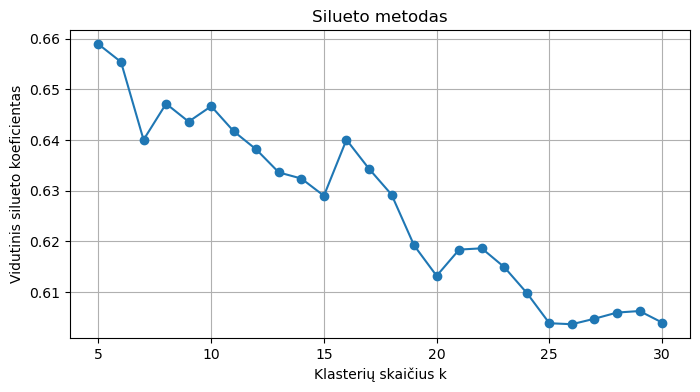

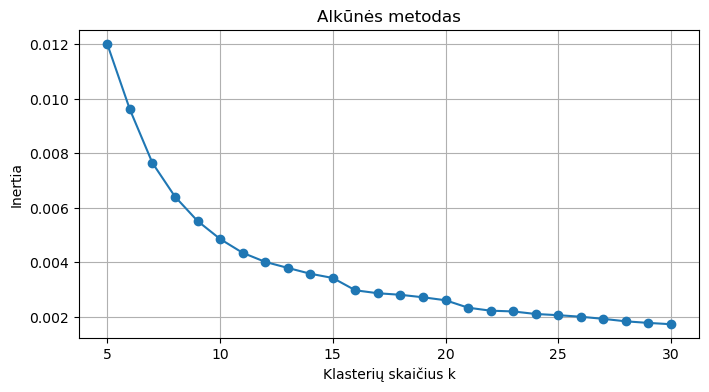

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(results_df_1["k"], results_df_1["silhouette"], marker="o")
plt.xlabel("Klasterių skaičius k")
plt.ylabel("Vidutinis silueto koeficientas")
plt.title("Silueto metodas")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(results_df_1["k"], results_df_1["inertia"], marker="o")
plt.xlabel("Klasterių skaičius k")
plt.ylabel("Inertia")
plt.title("Alkūnės metodas")
plt.grid(True)
plt.show()

In [29]:
best_row_1 = results_df_1.loc[results_df_1["silhouette"].idxmax()]
best_k_1 = int(best_row_1["k"])

print(f"Geriausias k pagal silhouette: {best_k_1}")
print(best_row_1)

Geriausias k pagal silhouette: 5
k             5.000000
silhouette    0.658898
inertia       0.012010
Name: 0, dtype: float64


In [30]:
model_1 = TimeSeriesKMeans(n_clusters=best_k_1, metric="dtw",
                         max_iter=10, random_state=5)

klasteriai_1=model_1.fit_predict(filtered_sequence_arrays_1)

In [31]:
print(filtered_metadata_df_1.shape)
print(klasteriai_1.shape)
print(np.unique(klasteriai_1, return_counts=True))
X = np.array(filtered_sequence_arrays_1)
print("lat min/max:", np.nanmin(X[:, :, 0]), np.nanmax(X[:, :, 0]))
print("lon min/max:", np.nanmin(X[:, :, 1]), np.nanmax(X[:, :, 1]))

print("pirma trajektorija:")
print(X[0][:5])

(91784, 7)
(91784,)
(array([0, 1, 2, 3, 4]), array([ 9110, 45287, 15630,  8798, 12959]))
lat min/max: -0.21969871428571253 0.21778908333333646
lon min/max: -0.3985824666666673 0.427246666666667
pirma trajektorija:
[[0.         0.        ]
 [0.00187398 0.00607527]
 [0.00374796 0.01215054]
 [0.00527869 0.01849928]
 [0.00679036 0.02485777]]


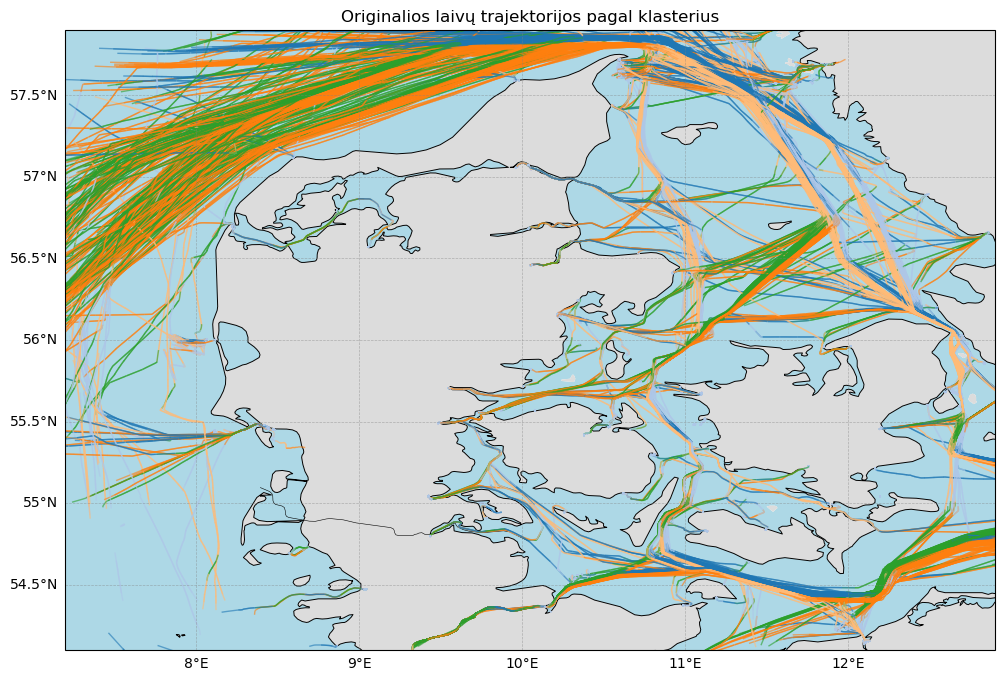

In [32]:

labels = np.array(klasteriai_1)             # klasteriai iš reliatyvių sekų
X = np.array(filtered_sequence_arrays_original_1)  # originalios lat/lon sekos

lon_min, lon_max = 7.2, 12.9
lat_min, lat_max = 54.1, 57.9

fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.LAND, facecolor="gainsboro")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)

for i in range(len(X)):
    lat = X[i, :, 0]
    lon = X[i, :, 1]

    valid = np.isfinite(lon) & np.isfinite(lat)

    ax.plot(
        lon[valid],
        lat[valid],
        color=plt.cm.tab20(int(labels[i]) % 20),
        alpha=0.6,
        linewidth=1,
        transform=ccrs.PlateCarree()
    )

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title("Originalios laivų trajektorijos pagal klasterius")
plt.show()

In [33]:
print("len(labels):", len(labels))
print("len(X):", len(X))
print("labels shape:", labels.shape)
print("X shape:", X.shape)

len(labels): 91784
len(X): 91784
labels shape: (91784,)
X shape: (91784, 20, 2)


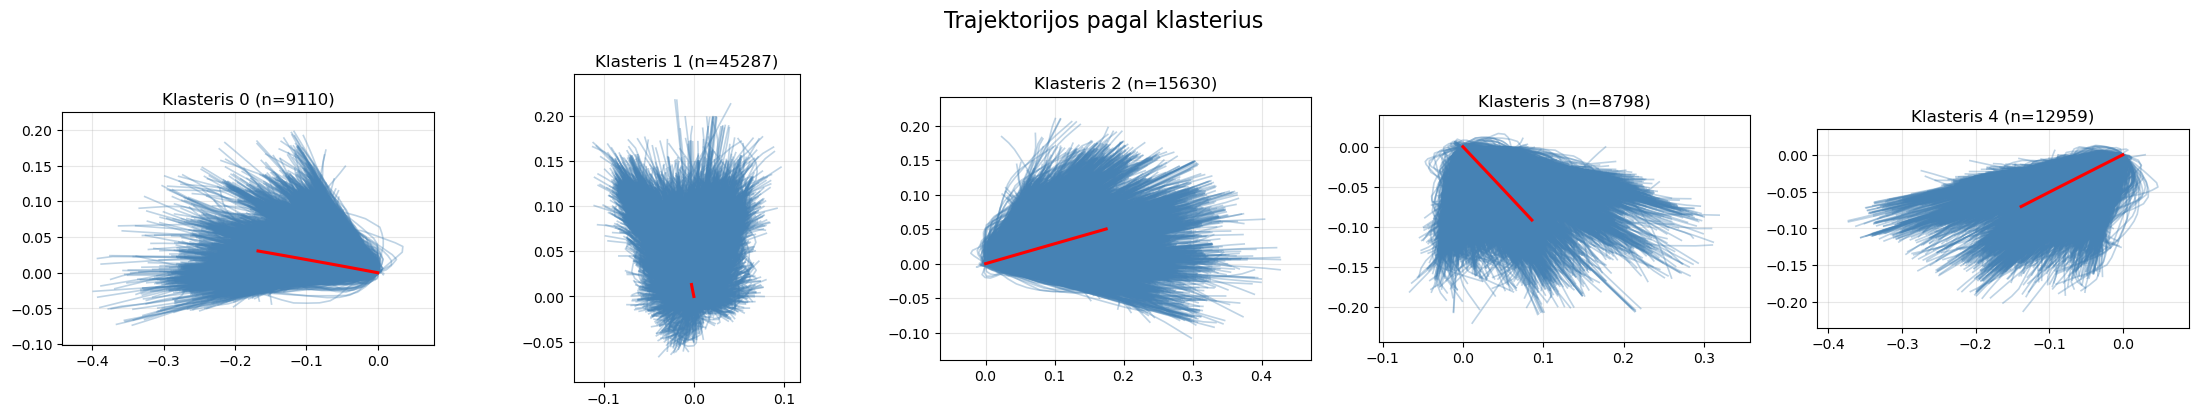

In [34]:
X = np.array(filtered_sequence_arrays_1)
labels = np.array(klasteriai_1)

n_clusters = len(np.unique(labels))
n_cols = 5
n_rows = math.ceil(n_clusters / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4.2 * n_rows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for k in range(n_clusters):
    ax = axes[k]
    idx = np.where(labels == k)[0]

    all_lon = []
    all_lat = []

    for i in idx:
        coords = X[i]
        lat = coords[:, 0]
        lon = coords[:, 1]
        valid = np.isfinite(lat) & np.isfinite(lon)

        if valid.any():
            ax.plot(lon[valid], lat[valid], color='steelblue', alpha=0.35, linewidth=1.2)
            all_lon.extend(lon[valid])
            all_lat.extend(lat[valid])

    if len(idx) > 0:
        mean_traj = np.nanmean(X[idx], axis=0)
        valid_mean = np.isfinite(mean_traj[:, 0]) & np.isfinite(mean_traj[:, 1])
        ax.plot(mean_traj[valid_mean, 1], mean_traj[valid_mean, 0], color='red', linewidth=2.2)

    if len(all_lon) > 0 and len(all_lat) > 0:
        xmin, xmax = np.min(all_lon), np.max(all_lon)
        ymin, ymax = np.min(all_lat), np.max(all_lat)

        xpad = max((xmax - xmin) * 0.1, 0.001)
        ypad = max((ymax - ymin) * 0.1, 0.001)

        ax.set_xlim(xmin - xpad, xmax + xpad)
        ax.set_ylim(ymin - ypad, ymax + ypad)

    ax.set_title(f'Klasteris {k} (n={len(idx)})')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Trajektorijos pagal klasterius', fontsize=16)
plt.tight_layout()
plt.show()

In [38]:
df_ship_2 = df_ship[['timestamp', 'mmsi', 'latitude', 'longitude', 'rot', 'sog', 'cog', 'heading']].copy()

In [39]:
# -----------------------------
# PARAMETERS
# -----------------------------
RESAMPLE_FREQ = '2min'
MAX_GAP = 3600          # 1 hour
MAX_ROT_GAP_STEPS = 2   # ROT interpoliuoti tik trumpiems tarpams
EDGE_FILL_STEPS = 1     # max kiek resample zingsniu pildom krastuose


# -----------------------------
# 1. SORT DATA
# -----------------------------
df_2 = df_ship_2.sort_values(['mmsi', 'timestamp']).copy()

for col in ['latitude', 'longitude', 'rot', 'sog', 'cog']:
    df_2[col] = pd.to_numeric(df_2[col], errors='coerce')


# -----------------------------
# 2. COMPUTE TIME GAPS + SEGMENTS
# -----------------------------
df_2['time_gap_sec'] = (
    df_2.groupby('mmsi')['timestamp']
    .diff()
    .dt.total_seconds()
)

df_2['new_block'] = (
    df_2['time_gap_sec'].isna() |
    (df_2['time_gap_sec'] > MAX_GAP)
)

df_2['block_id'] = (
    df_2.groupby('mmsi')['new_block']
    .cumsum()
)


# -----------------------------
# 3. HELPER FOR ANGLE INTERPOLATION
# -----------------------------
def interpolate_angle_time(series_deg, index, limit_inside=None):
    s = pd.Series(series_deg, index=index, dtype='float64')

    rad = np.deg2rad(s)
    sin_s = pd.Series(np.sin(rad), index=index)
    cos_s = pd.Series(np.cos(rad), index=index)

    sin_i = sin_s.interpolate(
        method='time',
        limit_area='inside',
        limit=limit_inside
    )
    cos_i = cos_s.interpolate(
        method='time',
        limit_area='inside',
        limit=limit_inside
    )

    angle = (np.rad2deg(np.arctan2(sin_i, cos_i)) + 360) % 360
    angle[(sin_i.isna()) | (cos_i.isna())] = np.nan
    return angle


# -----------------------------
# 4. RESAMPLING FUNCTION
# -----------------------------
def resample_ship_block_2(group, mmsi, block_id):
    if len(group) < 2:
        return None

    group = (
        group.sort_values('timestamp')
        .drop_duplicates('timestamp')
        .set_index('timestamp')
    )

    if group.index.min() == group.index.max():
        return None

    grid = pd.date_range(
        start=group.index.min().ceil(RESAMPLE_FREQ),
        end=group.index.max().floor(RESAMPLE_FREQ),
        freq=RESAMPLE_FREQ
    )

    if len(grid) == 0:
        return None

    tmp = group.reindex(group.index.union(grid)).sort_index()

    out = pd.DataFrame(index=tmp.index)

    # latitude / longitude
    out['latitude'] = tmp['latitude'].interpolate(method='time', limit_area='inside')
    out['longitude'] = tmp['longitude'].interpolate(method='time', limit_area='inside')

    # sog
    out['sog'] = tmp['sog'].interpolate(method='time', limit_area='inside')
    out['sog'] = out['sog'].ffill(limit=EDGE_FILL_STEPS).bfill(limit=EDGE_FILL_STEPS)

    # rot - tik trumpiems tarpams
    out['rot'] = tmp['rot'].interpolate(
        method='time',
        limit_area='inside',
        limit=MAX_ROT_GAP_STEPS
    )
    out['rot'] = out['rot'].ffill(limit=EDGE_FILL_STEPS).bfill(limit=EDGE_FILL_STEPS)

    # cog - kampine interpoliacija
    out['cog'] = interpolate_angle_time(tmp['cog'], tmp.index, limit_inside=None)

    # ribotas krastu uzpildymas
    out['cog'] = out['cog'].ffill(limit=EDGE_FILL_STEPS).bfill(limit=EDGE_FILL_STEPS)

    if 'heading' in tmp.columns:
        heading_fallback = interpolate_angle_time(tmp['heading'], tmp.index, limit_inside=None)
        heading_fallback = heading_fallback.ffill(limit=EDGE_FILL_STEPS).bfill(limit=EDGE_FILL_STEPS)
        out['cog'] = out['cog'].fillna(heading_fallback)

    #suvedam i 0-360 intervala, kad neturetiu neigiamu ar >360 reiksmiu
    out['cog'] = out['cog'] % 360

    tmp_final = out.loc[grid, ['latitude', 'longitude', 'rot', 'sog', 'cog']].reset_index()
    tmp_final = tmp_final.rename(columns={'index': 'timestamp'})
    tmp_final['mmsi'] = mmsi
    tmp_final['block_id'] = block_id

    return tmp_final[['timestamp', 'mmsi', 'block_id', 'latitude', 'longitude', 'rot', 'sog', 'cog']]


# -----------------------------
# 5. APPLY
# -----------------------------
parts_2 = []

for (mmsi, block_id), group in df_2.groupby(['mmsi', 'block_id']):
    res = resample_ship_block_2(group, mmsi, block_id)
    if res is not None and not res.empty:
        parts_2.append(res)

df_resampled_2 = pd.concat(parts_2, ignore_index=True)


# -----------------------------
# 6. OPTIONAL: ROT likucius paverciam 0
# -----------------------------
df_resampled_2['rot'] = df_resampled_2['rot'].fillna(0.0) #kodel?


# -----------------------------
# RESULT
# -----------------------------
print(df_resampled_2.shape)
print(df_resampled_2.isna().mean().sort_values(ascending=False))
df_resampled_2.head()

(940277, 8)
cog          0.013444
sog          0.000028
timestamp    0.000000
mmsi         0.000000
block_id     0.000000
latitude     0.000000
longitude    0.000000
rot          0.000000
dtype: float64


,timestamp,mmsi,block_id,latitude,longitude,rot,sog,cog
0,2025-09-21 09:22:00,205011000,2,54.153490,9.374533,0.0,7.188530,58.242979
1,2025-09-21 09:24:00,205011000,2,54.155364,9.380608,0.0,7.145520,62.549160
2,2025-09-21 09:26:00,205011000,2,54.157238,9.386684,0.0,7.102509,66.850282
3,2025-09-21 09:28:00,205011000,2,54.158768,9.393032,0.0,7.159474,67.159474
4,2025-09-21 09:30:00,205011000,2,54.160280,9.399391,0.0,7.200000,67.758996


In [43]:
x = df_resampled_2.sort_values(['mmsi', 'block_id', 'timestamp']).copy()

g = x.groupby(['mmsi', 'block_id'])
x['pos_in_block'] = g.cumcount()
x['block_size'] = g['timestamp'].transform('size')
x['is_edge'] = (x['pos_in_block'] == 0) | (x['pos_in_block'] == x['block_size'] - 1)

bad_rows = x[x['cog'].isna() & (~x['is_edge'])].copy()

print("Vidinių COG NaN skaičius:", len(bad_rows))

bad_segments = (
    bad_rows[['mmsi', 'block_id']]
    .drop_duplicates()
    .sort_values(['mmsi', 'block_id'])
)

print("Blogų segmentų skaičius:", len(bad_segments))
print(bad_segments.head(20))


# išmetam blogus segmentus
df_resampled_2_clean = (
    x.merge(bad_segments.assign(drop_me=1), on=['mmsi', 'block_id'], how='left')
     .query('drop_me != 1 or drop_me.isna()', engine='python')
     .drop(columns=['pos_in_block', 'block_size', 'is_edge', 'drop_me'])
     .reset_index(drop=True)
)

print("\nSena forma:", df_resampled_2.shape)
print("Nauja forma:", df_resampled_2_clean.shape)
#cia reiks segmenta trint

Vidinių COG NaN skaičius: 0
Blogų segmentų skaičius: 0
Empty DataFrame
Columns: [mmsi, block_id]
Index: []

Sena forma: (920102, 8)
Nauja forma: (920102, 8)


In [42]:
df_resampled_2 = df_resampled_2_clean.copy()
print(df_resampled_2.isna().mean().sort_values(ascending=False))

sog          0.000028
timestamp    0.000000
mmsi         0.000000
block_id     0.000000
latitude     0.000000
longitude    0.000000
rot          0.000000
cog          0.000000
dtype: float64


In [45]:
x = df_resampled_2.sort_values(['mmsi', 'block_id', 'timestamp']).copy()

g = x.groupby(['mmsi', 'block_id'])
x['pos_in_block'] = g.cumcount()
x['block_size'] = g['timestamp'].transform('size')
x['is_edge'] = (x['pos_in_block'] == 0) | (x['pos_in_block'] == x['block_size'] - 1)

sog_nan_not_on_edge = x[x['sog'].isna() & (~x['is_edge'])].copy()

bad_sog_segments = sog_nan_not_on_edge[['mmsi', 'block_id']].drop_duplicates()

print("Blogų segmentų skaičius:", len(bad_sog_segments))

# kiek NaN tame viename segmente
bad_sog_info = (
    x.merge(bad_sog_segments, on=['mmsi', 'block_id'], how='inner')
     .groupby(['mmsi', 'block_id'])
     .agg(
         n_rows=('timestamp', 'size'),
         n_sog_nan_total=('sog', lambda s: s.isna().sum()),
         n_sog_nan_inner=('sog', lambda s: s.iloc[1:-1].isna().sum() if len(s) > 2 else 0)
     )
     .reset_index()
)

print(bad_sog_info)

Blogų segmentų skaičius: 1
        mmsi  block_id  n_rows  n_sog_nan_total  n_sog_nan_inner
0  209938000         2      26               26               24


In [46]:
df_resampled_2 = df_resampled_2[
    ~((df_resampled_2['mmsi'] == 209938000) & (df_resampled_2['block_id'] == 2))
].copy() #ismemtam segmenta kuriame visur sog buvo NA

In [47]:
print(df_resampled_2.isna().mean().sort_values(ascending=False))

timestamp    0.0
mmsi         0.0
block_id     0.0
latitude     0.0
longitude    0.0
rot          0.0
sog          0.0
cog          0.0
dtype: float64


In [48]:
# TRAJECTORY WINDOWS / SEQUENCES - EXTENDED VERSION

WINDOW_SIZE = 20
STEP_SIZE = 10   # 50% overlap

df_seq_src_2 = (
    df_resampled_2[['timestamp', 'mmsi', 'block_id', 'latitude', 'longitude', 'rot', 'sog', 'cog']]
    .sort_values(['mmsi', 'block_id', 'timestamp'])
    .reset_index(drop=True)
    .copy()
)

sequence_metadata_2 = []
sequence_arrays_2 = []
original_sequences_2 = []

sequence_id = 0

for (mmsi, block_id), group in df_seq_src_2.groupby(['mmsi', 'block_id']):
    group = group.sort_values('timestamp').reset_index(drop=True)

    n = len(group)
    if n < WINDOW_SIZE:
        continue

    for start_idx in range(0, n - WINDOW_SIZE + 1, STEP_SIZE):
        end_idx = start_idx + WINDOW_SIZE
        window = group.iloc[start_idx:end_idx].copy()

        coords = window[['latitude', 'longitude']].to_numpy()
        coords_relative = coords - coords[0]

        extra_feats = window[['rot', 'sog', 'cog']].to_numpy()

        seq = np.hstack([coords_relative, extra_feats])

        seq_original = window[['latitude', 'longitude', 'rot', 'sog', 'cog']].to_numpy()

        if np.isnan(seq).any():
            continue

        sequence_arrays_2.append(seq)
        original_sequences_2.append(seq_original)

        sequence_metadata_2.append({
            'sequence_id': sequence_id,
            'mmsi': mmsi,
            'block_id': block_id,
            'start_time': window['timestamp'].iloc[0],
            'end_time': window['timestamp'].iloc[-1],
            'window_start_idx': start_idx,
            'window_end_idx': end_idx - 1
        })

        sequence_id += 1

sequence_metadata_df_2 = pd.DataFrame(sequence_metadata_2)

print("Sekų skaičius:", len(sequence_arrays_2))
print("Metadata shape:", sequence_metadata_df_2.shape)
sequence_metadata_df_2.head()

Sekų skaičius: 89792
Metadata shape: (89792, 7)


,sequence_id,mmsi,block_id,start_time,end_time,window_start_idx,window_end_idx
0,0,205011000,2,2025-09-21 09:22:00,2025-09-21 10:00:00,0,19
1,1,205011000,2,2025-09-21 09:42:00,2025-09-21 10:20:00,10,29
2,2,205011000,2,2025-09-21 10:02:00,2025-09-21 10:40:00,20,39
3,3,205011000,2,2025-09-21 10:22:00,2025-09-21 11:00:00,30,49
4,4,205011000,2,2025-09-21 10:42:00,2025-09-21 11:20:00,40,59


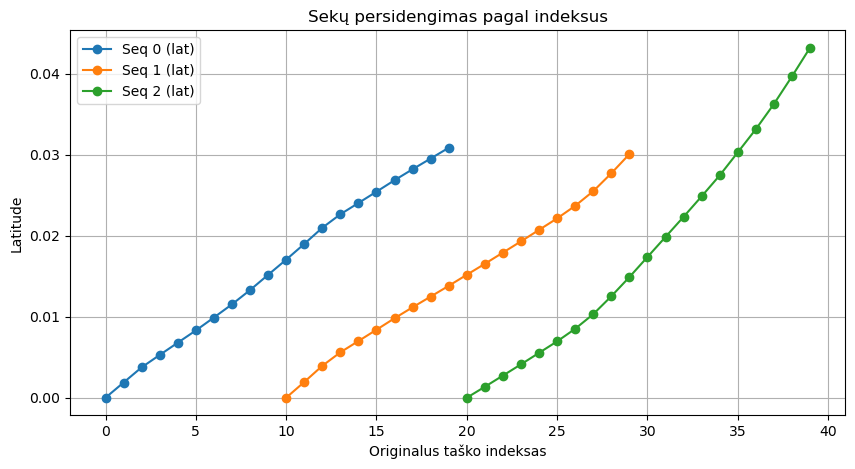

In [49]:
seq_ids = [0, 1, 2]

plt.figure(figsize=(10, 5))

for seq_id in seq_ids:
    coords = sequence_arrays_2[seq_id]
    start = sequence_metadata_df_2.iloc[seq_id]["window_start_idx"]
    x = np.arange(start, start + len(coords))

    plt.plot(x, coords[:, 0], marker='o', label=f'Seq {seq_id} (lat)')
    
plt.xlabel("Originalus taško indeksas")
plt.ylabel("Latitude")
plt.title("Sekų persidengimas pagal indeksus")
plt.legend()
plt.grid(True)
plt.show()

In [50]:
# IMAM VISAS SEKAS

vessel_seq_counts_all_2 = sequence_metadata_df_2.groupby('mmsi').size()

filtered_metadata_df_2 = (
    sequence_metadata_df_2
    .sort_values(['mmsi', 'block_id', 'sequence_id'])
    .reset_index(drop=True)
    .copy()
)

filtered_sequence_ids_2 = filtered_metadata_df_2['sequence_id'].tolist()
filtered_sequence_arrays_2 = [sequence_arrays_2[i] for i in filtered_sequence_ids_2]
filtered_sequence_arrays_original_2 = [original_sequences_2[i] for i in filtered_sequence_ids_2]

print("Laivų analizėje:", filtered_metadata_df_2['mmsi'].nunique())
print("Sekų analizėje:", len(filtered_sequence_arrays_2))

Laivų analizėje: 1005
Sekų analizėje: 89792


SITOJ VIETOJ SUABEJOJAU REIK NAUDOT STANDARTIZAVIMA AR MIN MAX NORMAVIMA. PADARIAU SU STANDARTIZAVIMU

In [51]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 1. Sekos -> numpy array
X_2 = np.array(filtered_sequence_arrays_2, dtype=float)

print("X_2 shape prieš scaling:", X_2.shape)

# 2. Perdarom į 2D, kad galėtume taikyti StandardScaler
n_samples_2, seq_len_2, n_features_2 = X_2.shape

X_2_2d = X_2.reshape(-1, n_features_2)

# 3. Scaling
scaler_2 = StandardScaler()
X_2_scaled_2d = scaler_2.fit_transform(X_2_2d)

# 4. Grąžinam atgal į 3D sekų formą
X_2_scaled = X_2_scaled_2d.reshape(n_samples_2, seq_len_2, n_features_2)

print("X_2 shape po scaling:", X_2_scaled.shape)
print("Feature means po scaling:", X_2_scaled.reshape(-1, n_features_2).mean(axis=0))
print("Feature std po scaling:", X_2_scaled.reshape(-1, n_features_2).std(axis=0))

X_2 shape prieš scaling: (89792, 20, 5)
X_2 shape po scaling: (89792, 20, 5)
Feature means po scaling: [-1.22164563e-14 -5.63177830e-15 -3.37058523e-13  2.87639618e-12
  8.00652933e-13]
Feature std po scaling: [1. 1. 1. 1. 1.]


In [52]:

# 1. Imtis silhouette skaičiavimui
rng = np.random.default_rng(42)
sample_size_2 = min(2000, len(X_2_scaled))
sample_idx_2 = rng.choice(len(X_2_scaled), size=sample_size_2, replace=False)
X_sample_2 = X_2_scaled[sample_idx_2]

print("X_sample_2 shape:", X_sample_2.shape)

# 2. DTW atstumų matrica tik kartą
print("Skaičiuojama DTW atstumų matrica...")
dist_matrix_2 = cdist_dtw(X_sample_2)

# 3. k reikšmės
k_values_2 = list(range(2, 11, 1))
results_2 = []

for k in k_values_2:
    print(f"Skaičiuojama k = {k} ...")

    model_2 = TimeSeriesKMeans(
        n_clusters=k,
        metric="dtw",
        max_iter=10,
        random_state=5
    )

    labels_2_sample = model_2.fit_predict(X_sample_2)

    sil_score_2 = silhouette_score(
        dist_matrix_2,
        labels_2_sample,
        metric="precomputed"
    )

    results_2.append({
        "k": k,
        "silhouette": sil_score_2,
        "inertia": model_2.inertia_
    })

results_df_2 = pd.DataFrame(results_2)
display(results_df_2)

X_sample_2 shape: (2000, 20, 5)
Skaičiuojama DTW atstumų matrica...
Skaičiuojama k = 2 ...
Skaičiuojama k = 3 ...
Skaičiuojama k = 4 ...
Skaičiuojama k = 5 ...
Skaičiuojama k = 6 ...
Skaičiuojama k = 7 ...
Skaičiuojama k = 8 ...
Skaičiuojama k = 9 ...
Skaičiuojama k = 10 ...


,k,silhouette,inertia
0,2,0.303187,60.714036
1,3,0.373659,41.805075
2,4,0.350678,35.686233
3,5,0.350098,31.716284
4,6,0.345560,26.893966
5,7,0.362302,24.537154
6,8,0.314028,23.843107
7,9,0.313660,23.054895
8,10,0.312672,22.520774


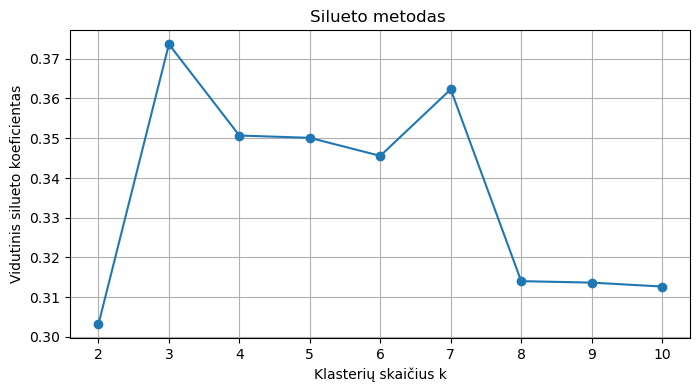

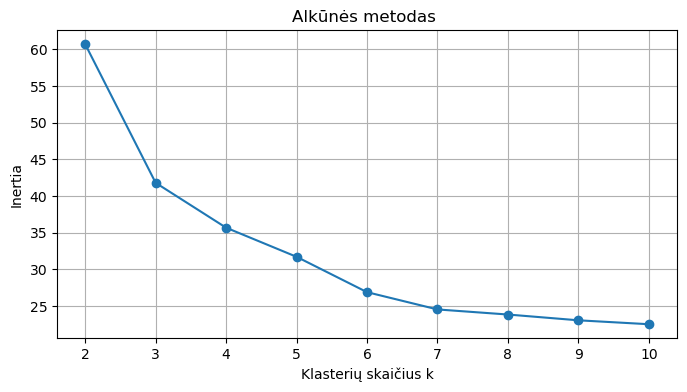

In [53]:
plt.figure(figsize=(8, 4))
plt.plot(results_df_2["k"], results_df_2["silhouette"], marker="o")
plt.xlabel("Klasterių skaičius k")
plt.ylabel("Vidutinis silueto koeficientas")
plt.title("Silueto metodas ")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(results_df_2["k"], results_df_2["inertia"], marker="o")
plt.xlabel("Klasterių skaičius k")
plt.ylabel("Inertia")
plt.title("Alkūnės metodas ")
plt.grid(True)
plt.show()

In [54]:
best_row_2 = results_df_2.loc[results_df_2["silhouette"].idxmax()]
best_k_2 = int(best_row_2["k"])

print(f"Geriausias k pagal silhouette: {best_k_2}")
print(best_row_2)

Geriausias k pagal silhouette: 3
k              3.000000
silhouette     0.373659
inertia       41.805075
Name: 1, dtype: float64


In [55]:
model_2_final = TimeSeriesKMeans(
    n_clusters=best_k_2,
    metric="dtw",
    max_iter=10,
    random_state=5
)

labels_2 = model_2_final.fit_predict(X_2_scaled)

pd.Series(labels_2).value_counts().sort_index()

0    37962
1    30419
2    21411
Name: count, dtype: int64

In [56]:
cluster_sizes_2 = pd.Series(labels_2).value_counts().sort_index()
print(cluster_sizes_2)

0    37962
1    30419
2    21411
Name: count, dtype: int64


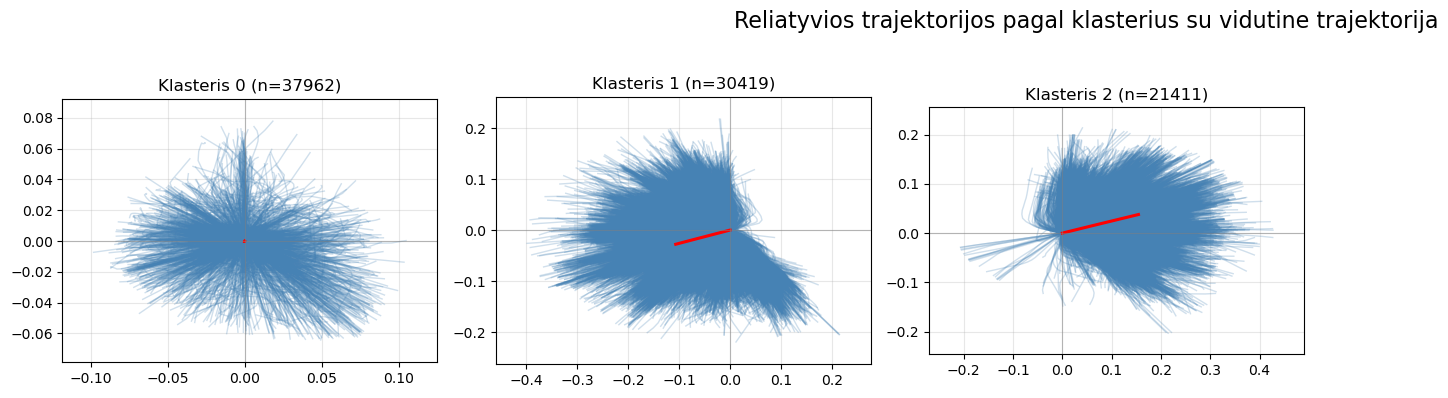

In [57]:

X = np.array(filtered_sequence_arrays_2)   
labels = np.array(labels_2)

n_clusters = len(np.unique(labels))
n_cols = 5
n_rows = math.ceil(n_clusters / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(22, 4.2 * n_rows),
    sharex=False,
    sharey=False
)
axes = np.array(axes).reshape(-1)

for k in range(n_clusters):
    ax = axes[k]
    idx = np.where(labels == k)[0]

    all_lon = []
    all_lat = []

    for i in idx:
        seq = X[i]

        # tik reliatyvios koordinatės
        lat = seq[:, 0]
        lon = seq[:, 1]

        valid = np.isfinite(lat) & np.isfinite(lon)

        if valid.any():
            ax.plot(
                lon[valid],
                lat[valid],
                color='steelblue',
                alpha=0.25,
                linewidth=1.0
            )
            all_lon.extend(lon[valid])
            all_lat.extend(lat[valid])

    if len(idx) > 0:
        mean_traj = np.nanmean(X[idx][:, :, :2], axis=0)
        valid_mean = np.isfinite(mean_traj[:, 0]) & np.isfinite(mean_traj[:, 1])

        ax.plot(
            mean_traj[valid_mean, 1],
            mean_traj[valid_mean, 0],
            color='red',
            linewidth=2.2
        )

    if len(all_lon) > 0 and len(all_lat) > 0:
        xmin, xmax = np.min(all_lon), np.max(all_lon)
        ymin, ymax = np.min(all_lat), np.max(all_lat)

        xpad = max((xmax - xmin) * 0.1, 0.001)
        ypad = max((ymax - ymin) * 0.1, 0.001)

        ax.set_xlim(xmin - xpad, xmax + xpad)
        ax.set_ylim(ymin - ypad, ymax + ypad)

    ax.axhline(0, color='gray', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.8, alpha=0.5)

    ax.set_title(f'Klasteris {k} (n={len(idx)})')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Reliatyvios trajektorijos pagal klasterius su vidutine trajektorija', fontsize=16)
plt.tight_layout()
plt.show()

In [58]:
print((filtered_metadata_df_2["mmsi"] == 273217380).any())
print((sequence_metadata_df_1["mmsi"] == 273217380).any())
print((df_ship["mmsi"] == 273217380).any()) 

True
True
True
